# Notebook 07 — Intraday Regime-Aware Market Making

**Paper**: Guéant, O. (2017). *Optimal Market Making*.
**Status**: **Innovation extension** — not in the paper. Explores piecewise-constant parameter regimes within a single trading session.

**Figures produced**:

| Figure | Content |
|--------|---------|
| 1 | Regime multipliers + spread response (static vs adaptive) |
| 2 | P&L histogram comparison |
| 3 | Inventory control comparison |

---

## Motivation

The paper assumes **constant** parameters $(A, k, \sigma)$ throughout the trading horizon. In reality, intraday microstructure varies significantly:

- **Open** (first ~30%): High volatility, high activity — news absorption, position-building.
- **Noon** (middle ~40%): Low volatility, low activity — lunch lull.
- **Close** (last ~30%): Rising volatility and activity — end-of-day rebalancing.

**Question**: Does a market maker who **adapts** quotes to regime changes outperform one who uses a single static policy?

We compare:
1. **Static policy**: Solve the ODE once with baseline parameters. Use for the entire session.
2. **Regime-aware policy**: Re-solve the ODE at each regime boundary with updated $(A, \sigma)$, using the **remaining** horizon.


## 1. Mathematical framework

### 1.1 Time-varying parameters

We extend the paper's model by allowing $A(t)$ and $\sigma(t)$ to be **piecewise constant**:

$$\Lambda^b_t(\delta) = A(t)\,e^{-k\delta}, \qquad dS_t = \sigma(t)\,dW_t$$

The ODE (Eq. 3.9) is valid within each regime, but with different coefficients.

### 1.2 Static policy

Solve the standard ODE with baseline parameters $(A_0, \sigma_0)$ over the full horizon $[0, T]$:

$$\partial_t \theta + \tfrac{1}{2}\gamma\sigma_0^2 q^2 - H^b_\gamma - H^a_\gamma = 0, \qquad \theta(T) = 0$$

This gives a single quote table $\delta^b(t, n)$, $\delta^a(t, n)$ used everywhere.

### 1.3 Regime-aware policy

At each regime boundary $t_r$, re-solve the ODE with updated parameters over the **remaining** horizon $[t_r, T]$:

$$\partial_t \theta_r + \tfrac{1}{2}\gamma\sigma_r^2 q^2 - H^b_{\gamma,r} - H^a_{\gamma,r} = 0, \qquad \theta_r(T) = 0$$

where $A_r = A_0 \cdot m^A_r$ and $\sigma_r = \sigma_0 \cdot m^\sigma_r$ are the regime-specific parameters. The quote table for $[t_r, t_{r+1})$ comes from the first segment of this local solve.

### 1.4 Regime definitions

| Regime | Time fraction | $A(t)/A_0$ | $\sigma(t)/\sigma_0$ |
|--------|--------------|-----------|---------------------|
| Open | $[0, 0.3T)$ | 1.45 | 1.50 |
| Noon | $[0.3T, 0.7T)$ | 0.60 | 0.55 |
| Close | $[0.7T, T]$ | 1.35 | 1.40 |

### 1.5 Expected outcome

The regime-aware policy should:
- **Widen spreads** during high-vol regimes (Open, Close) → more risk-averse.
- **Narrow spreads** during the Noon lull → capture more fills when risk is low.
- Achieve similar or better **risk-adjusted** P&L than the static policy.


## 2. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from pathlib import Path

import sys
sys.path.append(str(Path().resolve().parents[0]))

from asset.params import IG, GAMMA, T
from src.ode_solver_1d import solve_general

plt.style.use("seaborn-v0_8")
%matplotlib inline


## 3. Parameters

In [2]:

N_T = 480     # time steps (dt = 15 s)
N_SIM = 800   # Monte Carlo paths

times = np.linspace(0.0, T, N_T + 1)
Q = int(IG["Q"])

print(f"Asset: IG")
print(f"N_t:   {N_T}  (dt = {T/N_T:.1f} s)")
print(f"N_sim: {N_SIM}")
print(f"T:     {T} s = {T/3600:.1f} h")


Asset: IG
N_t:   480  (dt = 15.0 s)
N_sim: 800
T:     7200 s = 2.0 h


## 4. Build intraday regimes

In [3]:

def build_intraday_paths(base_params, t_grid):
    """Create piecewise A(t), sigma(t) paths with Open/Noon/Close regimes."""
    n = len(t_grid) - 1
    A_path = np.zeros(n)
    sigma_path = np.zeros(n)

    breaks = [0, int(0.3 * n), int(0.7 * n), n]
    regimes = [
        dict(A_mult=1.45, sigma_mult=1.50, name="Open"),
        dict(A_mult=0.60, sigma_mult=0.55, name="Noon"),
        dict(A_mult=1.35, sigma_mult=1.40, name="Close"),
    ]

    for r, (s, e) in enumerate(zip(breaks[:-1], breaks[1:])):
        A_path[s:e] = base_params["A"] * regimes[r]["A_mult"]
        sigma_path[s:e] = base_params["sigma"] * regimes[r]["sigma_mult"]

    return A_path, sigma_path, breaks, regimes

A_path, sigma_path, breaks, regimes = build_intraday_paths(IG, times)

print("Regime structure:")
for r, (s, e) in enumerate(zip(breaks[:-1], breaks[1:])):
    reg = regimes[r]
    print(f"  [{s:>3d}–{e:>3d}] ({times[s]:.0f}–{times[e]:.0f} s)  "
          f"{reg['name']:<6s}  A×{reg['A_mult']:.2f}  σ×{reg['sigma_mult']:.2f}")


Regime structure:
  [  0–144] (0–2160 s)  Open    A×1.45  σ×1.50
  [144–336] (2160–5040 s)  Noon    A×0.60  σ×0.55
  [336–480] (5040–7200 s)  Close   A×1.35  σ×1.40


## 5. Solve policies

In [4]:

def solve_regime_aware_tables(base_params, gamma, horizon, n_t, breaks, regimes):
    """Build quote tables by re-solving at each regime boundary."""
    Q = int(base_params["Q"])
    n_states = 2 * Q + 1
    db = np.full((n_t + 1, n_states), np.nan)
    da = np.full((n_t + 1, n_states), np.nan)

    for r, (s, e) in enumerate(zip(breaks[:-1], breaks[1:])):
        rem_steps = n_t - s
        rem_horizon = horizon * rem_steps / n_t

        p_reg = {**base_params,
                 "A": base_params["A"] * regimes[r]["A_mult"],
                 "sigma": base_params["sigma"] * regimes[r]["sigma_mult"]}

        sol = solve_general(p_reg, gamma, rem_horizon, xi=gamma, N_t=rem_steps)
        seg_len = e - s
        db[s:e, :] = sol["delta_bid"][:seg_len, :]
        da[s:e, :] = sol["delta_ask"][:seg_len, :]

    db[-1, :] = db[-2, :]
    da[-1, :] = da[-2, :]
    return db, da

print("Solving STATIC policy (baseline params, full horizon) ...")
t0 = time.time()
sol_static = solve_general(IG, GAMMA, T, xi=GAMMA, N_t=N_T)
db_static = sol_static["delta_bid"]
da_static = sol_static["delta_ask"]
print(f"  Done in {time.time()-t0:.2f} s")

print("Solving REGIME-AWARE policy (re-solve at each boundary) ...")
t0 = time.time()
db_adapt, da_adapt = solve_regime_aware_tables(IG, GAMMA, T, N_T, breaks, regimes)
print(f"  Done in {time.time()-t0:.2f} s")


Solving STATIC policy (baseline params, full horizon) ...
  Done in 0.31 s
Solving REGIME-AWARE policy (re-solve at each boundary) ...
  Done in 0.50 s


## 6. Simulate with time-varying market

In [5]:

def simulate_with_paths(db_table, da_table, base_params, A_path, sigma_path,
                        horizon, n_sim=2000, seed=7):
    """Simulate P&L under time-varying A(t), sigma(t) using supplied quote tables."""
    rng = np.random.default_rng(seed)
    k = base_params["k"]
    Delta = base_params["Delta"]
    Q = int(base_params["Q"])
    n_t = len(A_path)
    dt = horizon / n_t

    price = np.zeros((n_sim, n_t + 1))
    cash = np.zeros((n_sim, n_t + 1))
    inv = np.zeros((n_sim, n_t + 1), dtype=int)
    mtm = np.zeros((n_sim, n_t + 1))

    z = rng.standard_normal((n_sim, n_t))
    u_b = rng.uniform(size=(n_sim, n_t))
    u_a = rng.uniform(size=(n_sim, n_t))

    for m in range(n_sim):
        S, X, n = 0.0, 0.0, 0
        price[m, 0] = S; cash[m, 0] = X; inv[m, 0] = n
        for t_idx in range(n_t):
            i_lot = n + Q
            db = db_table[t_idx, i_lot]
            da = da_table[t_idx, i_lot]
            can_bid = (n < Q) and np.isfinite(db)
            can_ask = (n > -Q) and np.isfinite(da)

            S += sigma_path[t_idx] * np.sqrt(dt) * z[m, t_idx]

            if can_bid:
                if u_b[m, t_idx] < A_path[t_idx] * np.exp(-k * db) * dt:
                    n += 1; X -= (S - db) * Delta
            if can_ask:
                if u_a[m, t_idx] < A_path[t_idx] * np.exp(-k * da) * dt:
                    n -= 1; X += (S + da) * Delta

            price[m, t_idx+1] = S; cash[m, t_idx+1] = X
            inv[m, t_idx+1] = n; mtm[m, t_idx+1] = X + n*Delta*S

    pnl = cash[:, -1] + inv[:, -1] * Delta * price[:, -1]
    return dict(pnl=pnl, inventory=inv, mtm=mtm)

print(f"Simulating {N_SIM} trajectories (STATIC) ...")
t0 = time.time()
res_static = simulate_with_paths(db_static, da_static, IG, A_path, sigma_path, T,
                                  n_sim=N_SIM, seed=10)
print(f"  Done in {time.time()-t0:.1f} s")

print(f"Simulating {N_SIM} trajectories (REGIME-AWARE) ...")
t0 = time.time()
res_adapt = simulate_with_paths(db_adapt, da_adapt, IG, A_path, sigma_path, T,
                                 n_sim=N_SIM, seed=10)
print(f"  Done in {time.time()-t0:.1f} s")

pnl_s, pnl_a = res_static["pnl"], res_adapt["pnl"]
sharpe_s = np.mean(pnl_s) / max(np.std(pnl_s), 1e-12)
sharpe_a = np.mean(pnl_a) / max(np.std(pnl_a), 1e-12)

print(f"\n  {'Policy':<14s}  {'Mean':>10s}  {'Std':>10s}  {'Sharpe':>8s}")
print("  " + "─" * 46)
print(f"  {'Static':<14s}  {np.mean(pnl_s):>+10.0f}  {np.std(pnl_s):>10.0f}  {sharpe_s:>8.3f}")
print(f"  {'Regime-aware':<14s}  {np.mean(pnl_a):>+10.0f}  {np.std(pnl_a):>10.0f}  {sharpe_a:>8.3f}")


Simulating 800 trajectories (STATIC) ...
  Done in 1.1 s
Simulating 800 trajectories (REGIME-AWARE) ...
  Done in 1.0 s

  Policy                Mean         Std    Sharpe
  ──────────────────────────────────────────────
  Static               +8309       12963     0.641
  Regime-aware         +7527       11575     0.650


## 7. Figure 1 — Regime multipliers and spread response

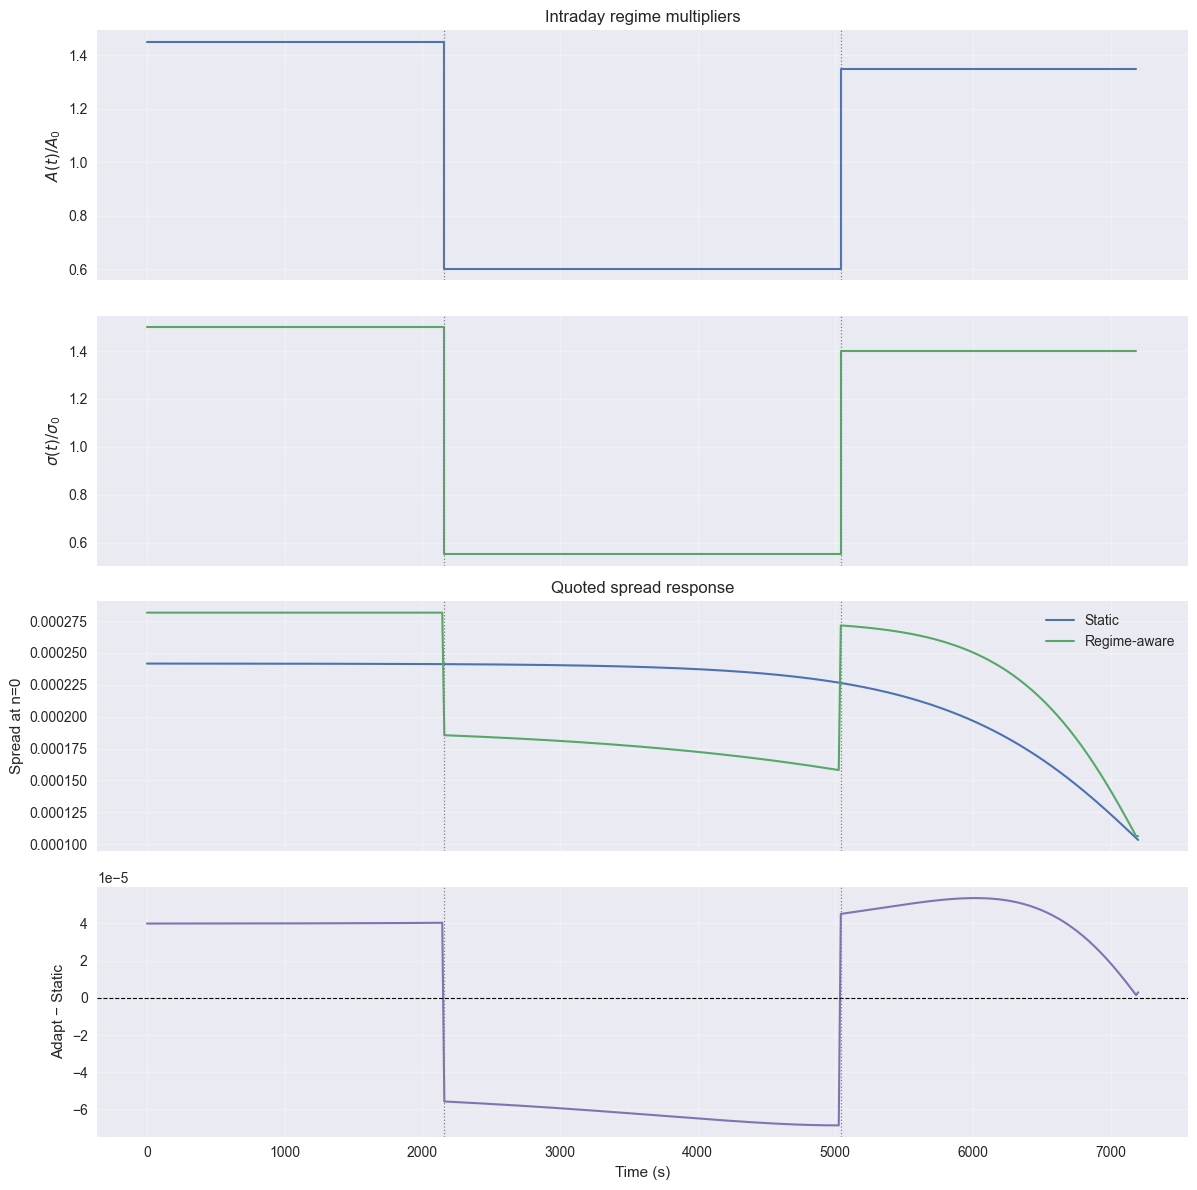

In [6]:

spread0_static = db_static[:, Q] + da_static[:, Q]
spread0_adapt = db_adapt[:, Q] + da_adapt[:, Q]
t_step = times[:-1]

fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

axes[0].step(t_step, A_path / IG["A"], where="post", lw=1.5, color="C0")
axes[0].set_ylabel("$A(t)/A_0$"); axes[0].set_title("Intraday regime multipliers")
axes[0].grid(alpha=0.3)

axes[1].step(t_step, sigma_path / IG["sigma"], where="post", lw=1.5, color="C1")
axes[1].set_ylabel("$\\sigma(t)/\\sigma_0$"); axes[1].grid(alpha=0.3)

axes[2].plot(times, spread0_static, label="Static", lw=1.5)
axes[2].plot(times, spread0_adapt, label="Regime-aware", lw=1.5)
axes[2].set_ylabel("Spread at n=0"); axes[2].set_title("Quoted spread response")
axes[2].legend(); axes[2].grid(alpha=0.3)

axes[3].plot(times, spread0_adapt - spread0_static, lw=1.5, color="C3")
axes[3].axhline(0, color="k", ls="--", lw=0.8)
axes[3].set_ylabel("Adapt − Static"); axes[3].set_xlabel("Time (s)")
axes[3].grid(alpha=0.3)

for b in breaks[1:-1]:
    for ax in axes:
        ax.axvline(times[b], color="gray", ls=":", lw=0.9)

fig.tight_layout()
plt.show()


## 8. Figure 2 — P&L histogram

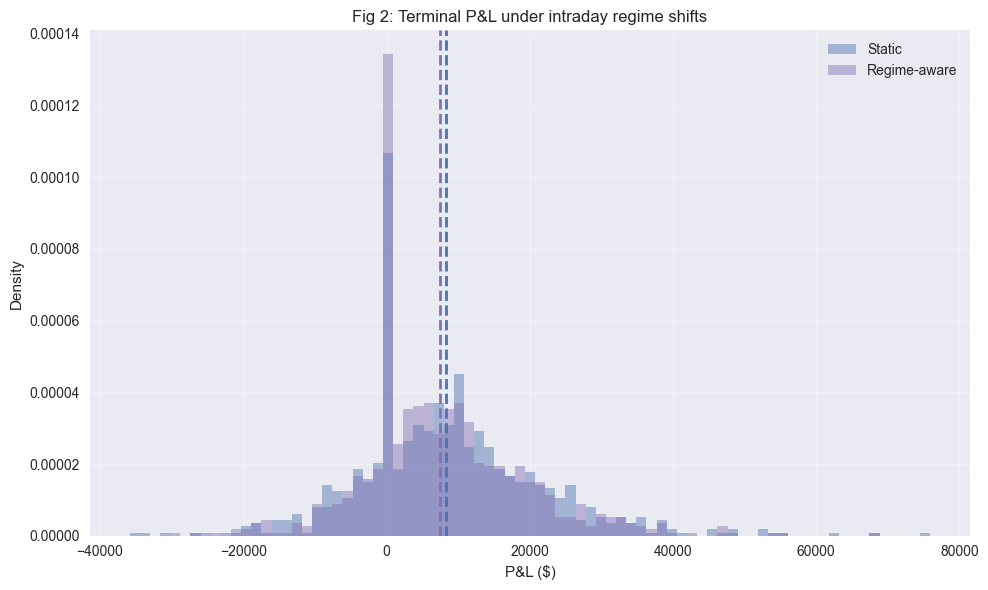

In [7]:

fig, ax = plt.subplots(figsize=(10, 6))
bins = np.linspace(min(pnl_s.min(), pnl_a.min()), max(pnl_s.max(), pnl_a.max()), 80)
ax.hist(pnl_s, bins=bins, density=True, alpha=0.45, label="Static", color="C0")
ax.hist(pnl_a, bins=bins, density=True, alpha=0.45, label="Regime-aware", color="C3")
ax.axvline(np.mean(pnl_s), color="C0", ls="--", lw=2)
ax.axvline(np.mean(pnl_a), color="C3", ls="--", lw=2)
ax.set_title("Fig 2: Terminal P&L under intraday regime shifts")
ax.set_xlabel("P&L ($)"); ax.set_ylabel("Density")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()


## 9. Figure 3 — Inventory control

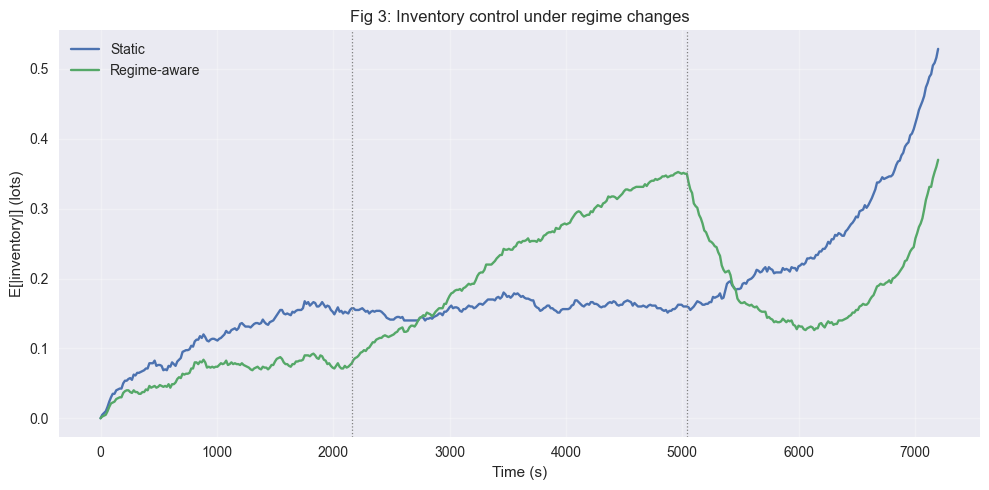

In [8]:

inv_s = res_static["inventory"].astype(float)
inv_a = res_adapt["inventory"].astype(float)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(times, np.mean(np.abs(inv_s), axis=0), lw=1.7, label="Static")
ax.plot(times, np.mean(np.abs(inv_a), axis=0), lw=1.7, label="Regime-aware")
ax.set_title("Fig 3: Inventory control under regime changes")
ax.set_xlabel("Time (s)"); ax.set_ylabel("E[|inventory|] (lots)")
ax.legend(); ax.grid(alpha=0.3)
for b in breaks[1:-1]:
    ax.axvline(times[b], color="gray", ls=":", lw=0.9)
fig.tight_layout(); plt.show()


## 10. Summary

The regime-aware policy adapts its spread to intraday conditions:
- **Wider** during high-vol regimes → better risk control.
- **Narrower** during calm periods → captures more fills at lower risk.

Whether this translates to improved Sharpe depends on the magnitude of regime shifts and the fill rate.

**Limitation**: The regime-aware policy requires **knowing** when regimes change. In practice, the market maker must **infer** regime transitions — which motivates Notebook 08's Bayesian approach.
